# <center><strong>Bank Customer Churn Analysis</strong></center>
--------------------------------


#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

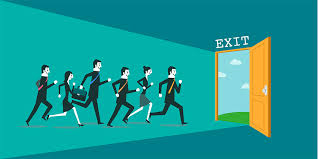

In [1]:
from IPython.display import Image
Image(filename='Bank.jpeg')

--------------------------------
--------------------------------
--------------------------------

## **Import Libraries**


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.show()

def kde(data, col):
    plt.figure(figsize=(14,	4))
    sns.kdeplot(data[col], fill=True,	color='red', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

---------------------------------------
---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [4]:
df = pd.read_csv("bank customer churn dataset.csv")

In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

0

------------------------
------------------------
### **Data Cleaning**
------------------------

In [11]:
df.rename(columns={'HasCrCard': 'Has credit card','IsActiveMember':'Is Active Member','CreditScore':'Credit Score',
                   'NumOfProducts':'Number Of Products','EstimatedSalary':'Estimated Salary','Exited':'Churned'} ,inplace=True)

In [12]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

-----------------------------------------
-----------------------------------------

### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Credit Score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
Number Of Products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
Has credit card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
Is Active Member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
Estimated Salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Churned,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


-----------------------------------

#### **Checking Correlation between the features**

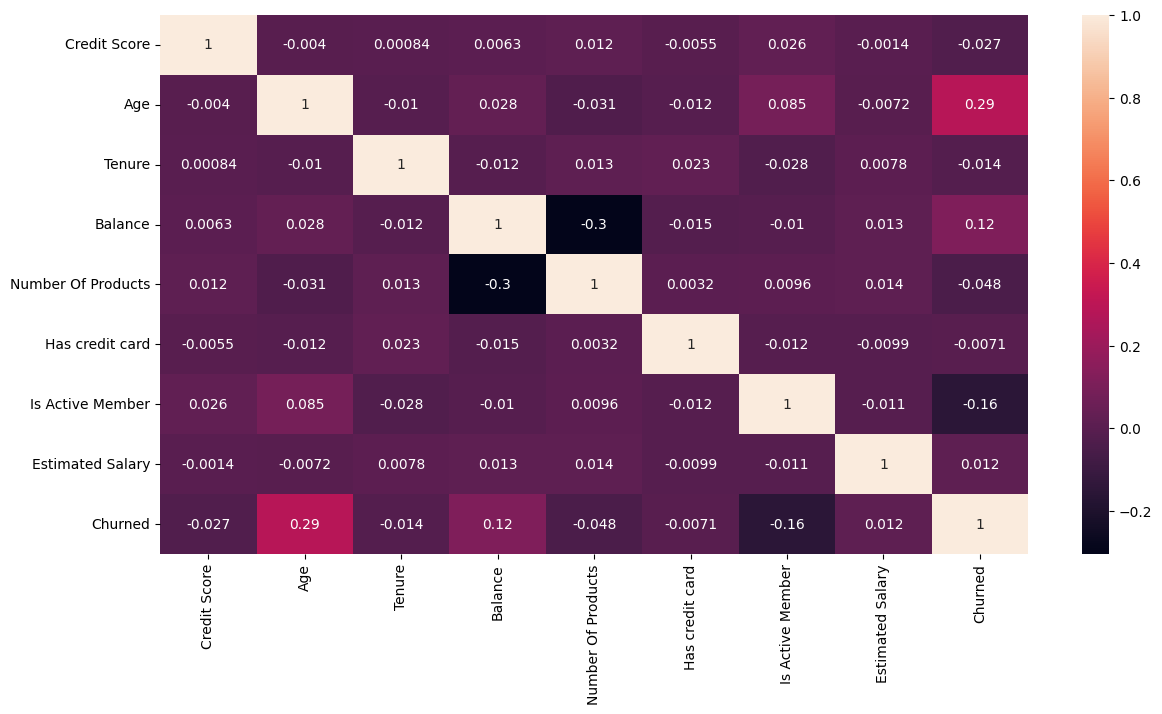

In [14]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

- ##### There is a **normal positive correlation (0.3)** between **Age** and **Exited** 
- ##### There is a **normal negative correlation (-0.3)** between **Balance** and **Number Of Products** 


------------------------------------------
------------------------------------------

## **Feature Extraction**

-----------------------------

In [15]:
def ageGroup(age):
    age = int(age)
    if age <= 40:
        return 'Young Adults'
    elif age > 40 and age < 60:
        return 'Middle-aged Adults'
    else :
        return 'Old Adults'
    
df['Age group'] = df['Age'].apply(lambda x : ageGroup(x))

In [16]:
df['Age group'].value_counts()

Age group
Young Adults          6419
Middle-aged Adults    3055
Old Adults             526
Name: count, dtype: int64

----------------------------------

In [17]:
def balanceGroup(balance):
    balance = float(balance)
    if balance > 0:
        return 'Funded account'
    elif balance == 0:
        return 'Empty account'
    else:
        return 'Overdrawn account'

df['Balance category'] = df['Balance'].apply(lambda x : balanceGroup(x))

In [18]:
df['Balance category'].value_counts()

Balance category
Funded account    6383
Empty account     3617
Name: count, dtype: int64

-----------------------------

In [19]:
def activeGroup(actAcc):
    actAcc = int(actAcc)
    if actAcc == 1:
        return 'Active'
    else:
        return 'Dormant'

df['Account status'] = df['Is Active Member'].apply(lambda x : activeGroup(x))

In [20]:
df['Account status'].value_counts()

Account status
Active     5151
Dormant    4849
Name: count, dtype: int64

------------------------------------

In [21]:
def cardGroup(card):
    card = int(card)
    if card == 1:
        return 'Has a card'
    else:
        return 'No'

df['Has credit card'] = df['Has credit card'].apply(lambda x : cardGroup(x))

In [22]:
df['Has credit card'].value_counts()

Has credit card
Has a card    7055
No            2945
Name: count, dtype: int64

--------------------------------

In [23]:
def categorize_credit(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'

df['Credit Score Category'] = df['Credit Score'].apply(categorize_credit)

In [24]:
df['Credit Score Category'].value_counts()

Credit Score Category
Fair         3331
Good         2428
Poor         2362
Very Good    1224
Excellent     655
Name: count, dtype: int64

-----------------------

In [25]:
def categorize_Estimated_Salary(Salary):
    if Salary < 50000:
        return 'Low Salary'
    elif Salary < 100000:
        return 'Medium Salary'
    elif Salary < 150000:
        return 'High Salary'
    else:
        return 'Very High Salary'

df['Estimated Salary Category'] = df['Estimated Salary'].apply(categorize_Estimated_Salary)

In [26]:
df['Estimated Salary Category'].value_counts()

Estimated Salary Category
High Salary         2555
Medium Salary       2537
Very High Salary    2455
Low Salary          2453
Name: count, dtype: int64

------------------------------------

In [27]:
df['BalanceSalaryRatio'] = df['Balance'] / df['Estimated Salary']

In [28]:
df[['Balance', 'Estimated Salary', 'BalanceSalaryRatio']].head()

,Balance,Estimated Salary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


In [29]:
#df.to_excel('bank customer churn new dataset.xlsx',index=False)

----------------------------
----------------------------


## **Analysis**

--------------------------------
- ### ***Churn Analysis***
---------------------------------

In [30]:
p_churn = len(df[df['Churned']==1])/len(df)
print(f'{p_churn*100:.2f} %')

20.37 %


In [31]:
# Expected value
n = 1000
expected = n * p_churn
print(f'Expected churn people : {round(expected)}')

Expected churn people : 204


In [32]:
variance = p_churn * (1 - p_churn) / n
std = np.sqrt(variance)
print("Variance:", variance)
print(f'Standard Error : {std*100:.2f} %')

Variance: 0.00016220630999999998
Standard Error : 1.27 %


##### We took different samples from customers, and the percentage change will typically be 1.27%

In [33]:
# Confidence Interval for 95 %
# Confidence Interval = p ​± 1.96 × Standard Error
CI1 = p_churn + 1.96 * std
CI2 = p_churn - 1.96 * std

print(f'[{CI2:0.2f} , {CI1:0.2f}]')

[0.18 , 0.23]


#### We are 95% confident that the true customer exit rate lies between 17.9% and 22.9%

In [34]:
# (CI1-CI2)*100 = 5 ---> narrow interval

In [35]:
# Interval of exited customers
lower_customers = 0.18*n
upper_customers = 0.23*n
print(f'[{upper_customers:0.0f} , {lower_customers:0.0f}] customers')

[230 , 180] customers


#### Based on the sample, the expected number of churned customers is 204 out of 1000
#### A 95% confidence interval estimates that the true number of churned customers likely falls between 179 and 229 customers

------------------------------
- ### ***Analysis of Gender and Age vs Churn***
------------------------------- 

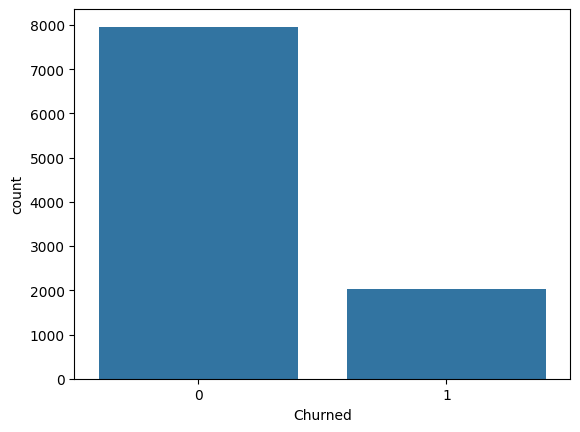

In [36]:
countplot(df,'Churned')

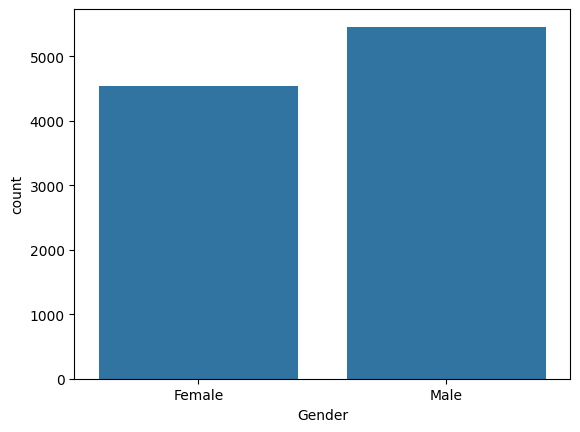

In [37]:
countplot(df,'Gender')

- ##### **Age distibution by gender**

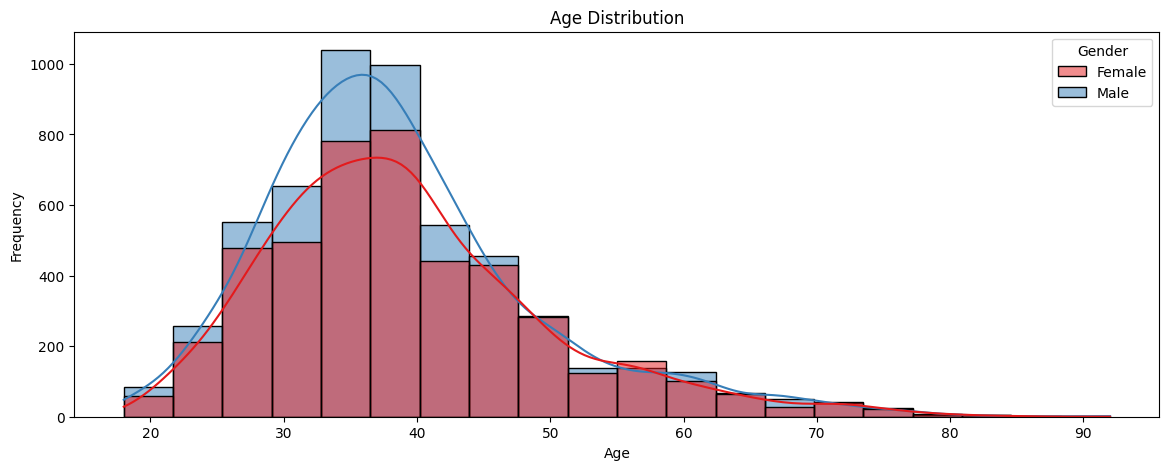

In [38]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='Age', hue='Gender', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

##### **The male age distribution is represented by the blue bars and curve.**

##### **The peak frequency for males is slightly older than for females, peaking around the late 30s to early 40s.**

##### **The count of males is consistently higher than females across the majority of the age range shown.**


----------------------
- #### **Comparison of Churn between Males and Females by correlation and probability**
-------------------------

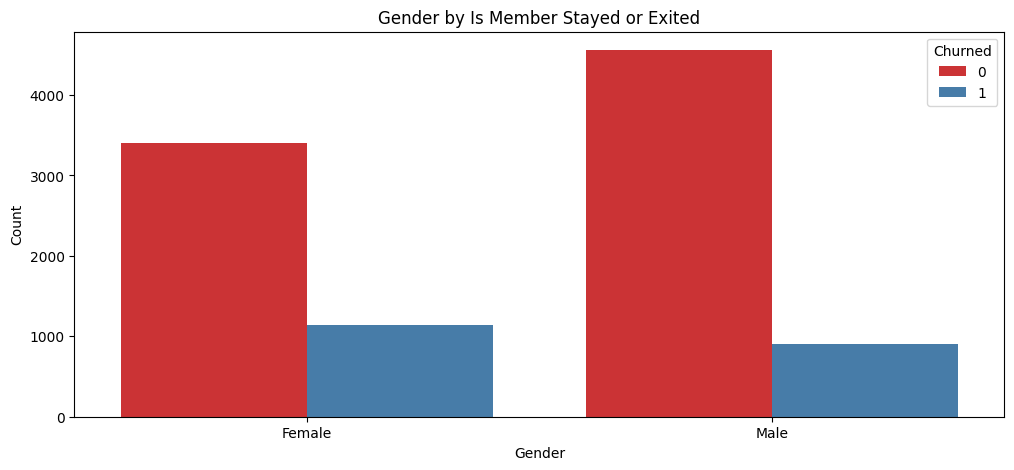

In [39]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x = 'Gender', hue='Churned',palette='Set1')
plt.title('Gender by Is Member Stayed or Exited')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [40]:
crosstab = pd.crosstab(df['Gender'], df['Churned'])
crosstab

Churned,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [41]:
rs = stats.chi2_contingency(crosstab)
print(rs[3])
print('p_val : ',rs[1])
if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

[[3617.5909  925.4091]
 [4345.4091 1111.5909]]
p_val :  2.2482100097131755e-26
There is a significant difference ---> H0 is rejected


In [42]:
p_churn_given_male = len(df[(df['Churned']==1) & (df['Gender']=='Male')]) / len(df[df['Gender']=='Male'])
print(f'P(churned | male) : {p_churn_given_male*100:.2f} %')

P(churned | male) : 16.46 %


In [43]:
p_female_given_churned = len(df[(df['Churned']==1) & (df['Gender']=='Female')]) / len(df[df['Gender']=='Female']) 
print(f'P(churned ∣ female) : {p_female_given_churned*100:.2f} %')

P(churned ∣ female) : 25.07 %


#### **Statistical Validation**
##### The Chi-Square test showed a very strong statistically significant relationship (p-value ≈ 2.25 × 10⁻²⁶) between customer gender and their decision to leave the service. This means that the difference in leaving behavior between males and females is not coincidental, but rather a real and consistent pattern in the data.

#### **Gap Analysis**
##### By comparing observed and expected frequencies, it was found that females tend to leave the service at a higher rate than statistically expected, while males show greater stability.

-   ##### Female dropout rate: 25.07% (approximately one in four).

-   ##### Male dropout rate: 16.46% (approximately one in six).

#### **Business Insight**
##### The results indicate a "value gap" in the female customer segment. Either the current offerings don't meet their expectations, or competitors are offering more attractive alternatives.

#### **Strategic Recommendation:** Similar to successful models in the banking sector (such as the "Sayidaty" offer), it is advisable to conduct qualitative analysis or targeted surveys of women to understand the reasons for leaving, and then design "tailored offers" aimed at increasing loyalty in this segment. This will directly lead to a significant reduction in the company's overall bounce rate.

--------------------------------
- #### **Comparison of Churn between Age groups by correlation and probability**
-------------------------------

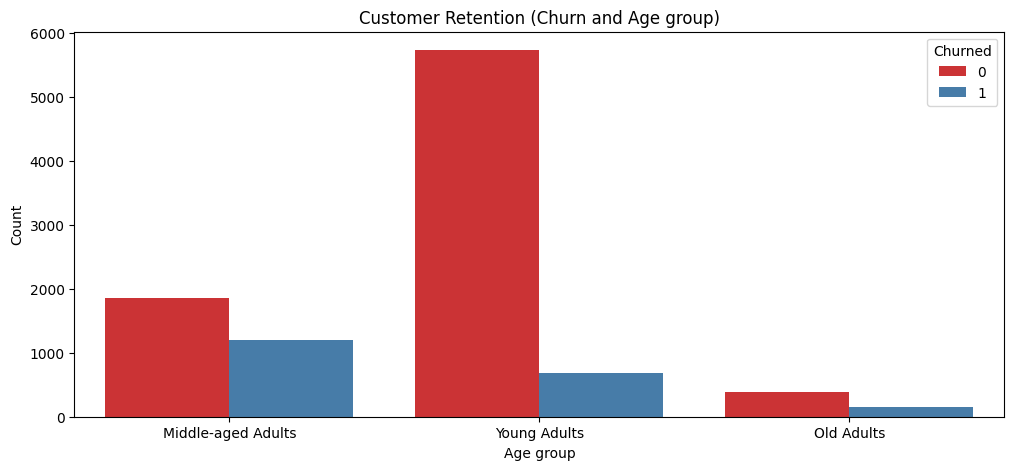

In [44]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Age group', hue='Churned',palette='Set1')
plt.title('Customer Retention (Churn and Age group)')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.show()

In [45]:
crosstab = pd.crosstab(df['Age group'],df['Churned'])
crosstab

Churned,0,1
Age group,,
Middle-aged Adults,1851,1204
Old Adults,379,147
Young Adults,5733,686


In [46]:
rs = stats.chi2_contingency(crosstab)
print(rs[3])
print('p_val : ',rs[1])
if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

[[2432.6965  622.3035]
 [ 418.8538  107.1462]
 [5111.4497 1307.5503]]
p_val :  1.2965157989610134e-233
There is a significant difference ---> H0 is rejected


- ##### Old adults Churn probability

In [47]:
p_old_adults_given_churned = len(df[(df['Churned']==1) & (df['Age group']=='Old Adults')])/len(df[df['Churned']==1])

p_intersection_old_adults_churn = p_churn * p_old_adults_given_churned
print(f'P(churned ∩ old adults) : {p_intersection_old_adults_churn*100:.2f} %')

P(churned ∩ old adults) : 1.47 %


- ##### Middle age adults Churn probability

In [48]:
p_middle_age_adults_given_churned = len(df[(df['Churned']==1) & (df['Age group']=='Middle-aged Adults')])/len(df[df['Churned']==1])

p_intersection_Middle_aged_Adults_churn = p_churn * p_middle_age_adults_given_churned
print(f'P(churned ∩ Middle-aged Adults) : {p_intersection_Middle_aged_Adults_churn*100:.2f} %')

P(churned ∩ Middle-aged Adults) : 12.04 %


- ##### Young adults Churn probability

In [49]:
p_intersection_young_adults_churn = p_churn - (p_intersection_old_adults_churn + p_intersection_Middle_aged_Adults_churn) 
print(f'P(churned ∩ Middle_aged_Adults) : {p_intersection_young_adults_churn*100:.2f} %')

P(churned ∩ Middle_aged_Adults) : 6.86 %


##### Age is a significant factor in predicting of churn
##### The Middle-aged Adults category is leaving at a rate that doubles statistical projections
##### Retention campaigns and targeted offers should be specifically aimed at this demographic, while "Young Adults" can currently be considered a stable customer base.

--------------------------------
- #### **Comparison of Churn between Age groups and age group by correlation and probability**
-------------------------------

In [50]:
crosstab = pd.crosstab([df['Gender'],df['Age group']],df['Churned'])
crosstab

Churned                       0    1
Gender Age group                    
Female Middle-aged Adults   798  665
       Old Adults           159   82
       Young Adults        2447  392
Male   Middle-aged Adults  1053  539
       Old Adults           220   65
       Young Adults        3286  294

In [51]:
rs = stats.chi2_contingency(crosstab)
print('pval ' ,rs[1])
print(rs[3])

if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

pval  3.8043226328822106e-252
[[1164.9869  298.0131]
 [ 191.9083   49.0917]
 [2260.6957  578.3043]
 [1267.7096  324.2904]
 [ 226.9455   58.0545]
 [2850.754   729.246 ]]
There is a significant difference ---> H0 is rejected


##### The critical point: Middle-aged women (middle-aged women) are at risk of being overrepresented, with their actual numbers exceeding statistical estimates by 123%.

##### The interplay of factors: "Gender" alone is insufficient to explain the situation; the gender gap has clearly widened in middle age, while simultaneously approaching youth.

##### Smart marketing: Comprehensive improvements should be specifically targeted at this age group to maximize the return on marketing costs.

-----------------------------
- #### **Comparison of Churn probability between Countries**
------------------------------

- ##### France Churn probability

In [52]:
p_france_given_churned = len(df[(df['Geography']=='France') & (df['Churned']==1)])/len(df[df['Churned']==1])
p_intersection_france_churn = p_churn * p_france_given_churned
print(f'P(churned ∩ france) : {p_intersection_france_churn *100:.2f} %')

P(churned ∩ france) : 8.10 %


- ##### Spain Churn probability

In [53]:
p_spain_given_churned = len(df[(df['Geography']=='Spain') & (df['Churned']==1)])/len(df[df['Churned']==1])
p_intersection_spain_churn = p_churn * p_spain_given_churned
print(f'P(churned ∩ spain) : {p_intersection_spain_churn *100:.2f} %')

P(churned ∩ spain) : 4.13 %


- ##### Germany Churn probability

In [54]:
p_intersection_germany_churn = p_churn - (p_intersection_france_churn + p_intersection_spain_churn)
print(f'P(churned ∩ germany) : {p_intersection_germany_churn *100:.2f} %')

P(churned ∩ germany) : 8.14 %


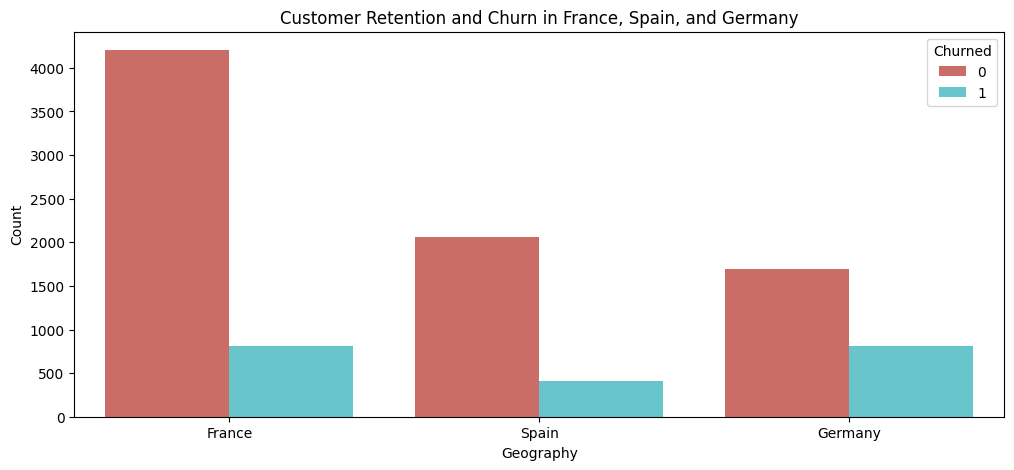

In [55]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Geography', hue='Churned',palette='hls')
plt.title('Customer Retention and Churn in France, Spain, and Germany')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

- ##### **France has the largest total customer base.**

- ##### **The number of customers who exited is roughly the same for France and Germany, despite France having a much larger total customer base.**

- ##### **The number of customers who exited is the lowest in Spain.**

- ##### **When looking at the proportion of customers who exited, Germany has the highest churn rate, followed by France. Spain has the lowest churn rate.**
---------------------------------

- #### **Effect of hight Salary on the possibility of leaving**
----------------------------------

In [56]:
group0 = df[df['Churned'] == 0]['Estimated Salary']
group1 = df[df['Churned'] == 1]['Estimated Salary']
    
t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)

print('p_val',p_val)

if p_val < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p_val 0.22892461305145798
There is not a significant difference ---> H0 is not rejacted


In [57]:
p_estimated_salary_gt_150000 = len(df[df['Estimated Salary'] >= 150000])/len(df)
p_estimated_salary_gt_150000

0.2455

In [58]:
p_intersection = len(df[(df['Churned'] == 1) & (df['Estimated Salary'] >= 150000)]) / len(df)
print(f"P(churned ∩ estimated salary) = {p_intersection}") 

P(churned ∩ estimated salary) = 0.0527


In [59]:
p_conditional = p_intersection / p_estimated_salary_gt_150000
print(f"P(churned | estimated salary) = {p_conditional*100:.2f} %")

P(churned | estimated salary) = 21.47 %


#### P(churned | estimated salary) > p_churn that's mean current employees tend to leave their current bank for a higher rating

------------------------------------

- ##### **Effect of active member or no on the possibility of leaving**
-----------------------------------

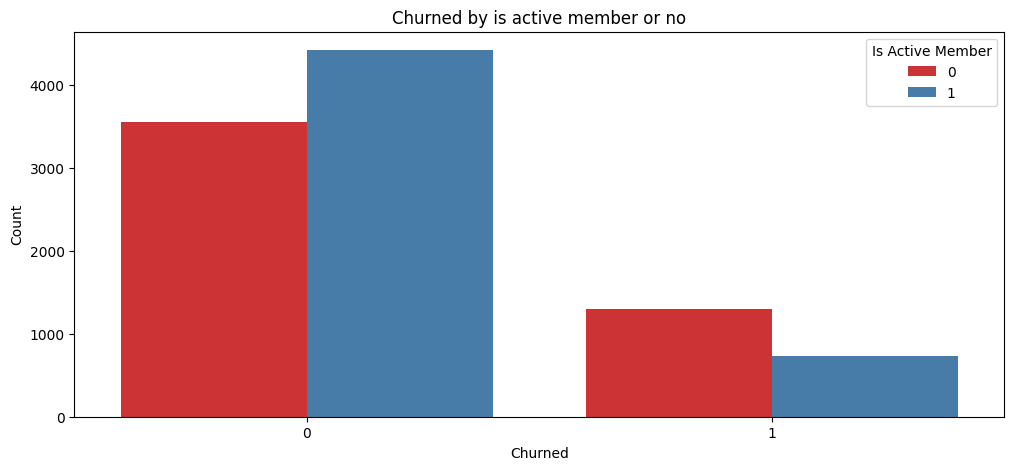

In [60]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Is Active Member', palette='Set1')
plt.title('Churned by is active member or no')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [61]:
crosstab = pd.crosstab(df['Account status'],df['Churned'])
crosstab

Churned,0,1
Account status,,
Active,4416,735
Dormant,3547,1302


In [62]:
Odds_Ratio = (1302 / 3547)/(735 / 4416)
print(f'Odds_Ration : {Odds_Ratio:.2f}')

Odds_Ration : 2.21


#### An inactive customer has a 2.3 of probability of churn greater than an active customer

In [63]:
rs = stats.chi2_contingency(crosstab)
print('pval ' ,rs[1])
print(rs[3])

if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

pval  8.785858269303832e-55
[[4101.7413 1049.2587]
 [3861.2587  987.7413]]
There is a significant difference ---> H0 is rejected


#### The results of the test confirm a very strong and statistically significant correlation between account status and customer turnover. The analysis shows that customers with dormant accounts are almost twice as likely to leave the bank compared to active customers, making dormancy a critical predictor of turnover.

#### Offering incentives to activate these accounts is an effective solution for reducing exit risk and increasing customer loyalty.

----------------------------
- ##### **Effect of balance status on possibility of leaving**
-----------------------------------

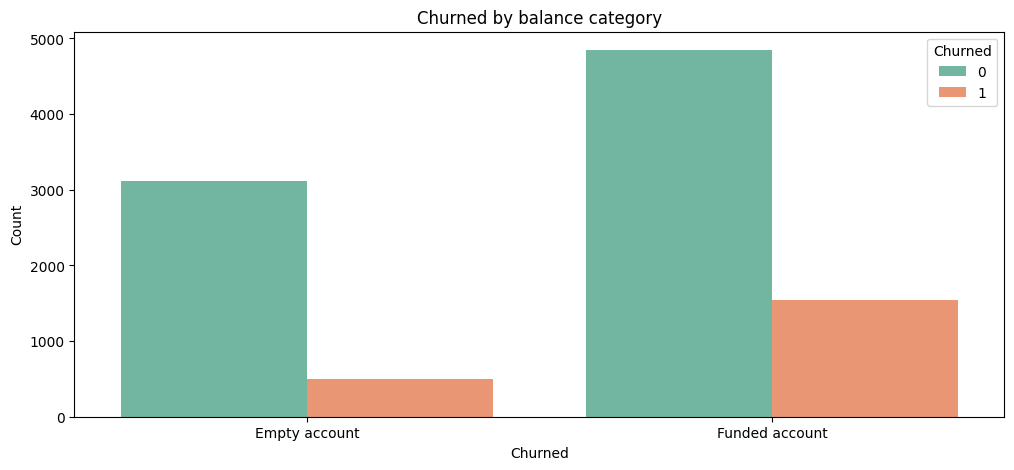

In [64]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Balance category', hue='Churned', palette='Set2')
plt.title('Churned by balance category')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [65]:
crosstab = pd.crosstab(df['Balance category'],df['Churned'])
crosstab

Churned,0,1
Balance category,,
Empty account,3117,500
Funded account,4846,1537


In [66]:
rs = stats.chi2_contingency(crosstab)
print('pval : ',rs[1])
print(rs[3])

if rs[1] < 0.05 : 
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

pval :  2.752618152604527e-34
[[2880.2171  736.7829]
 [5082.7829 1300.2171]]
There is a significant difference ---> H0 is rejected


#### Empty accounts: 500 / 3617 = 13.8%
#### Funded accounts: 1537 / 6383 = 24.1%
#### Funded account holders leave at a rate more than double that of empty accounts. The very small p-value confirms that this difference is statistically significant.

---------------------------
- ##### **Effect of tenure on possibility of leaving**
---------------------------


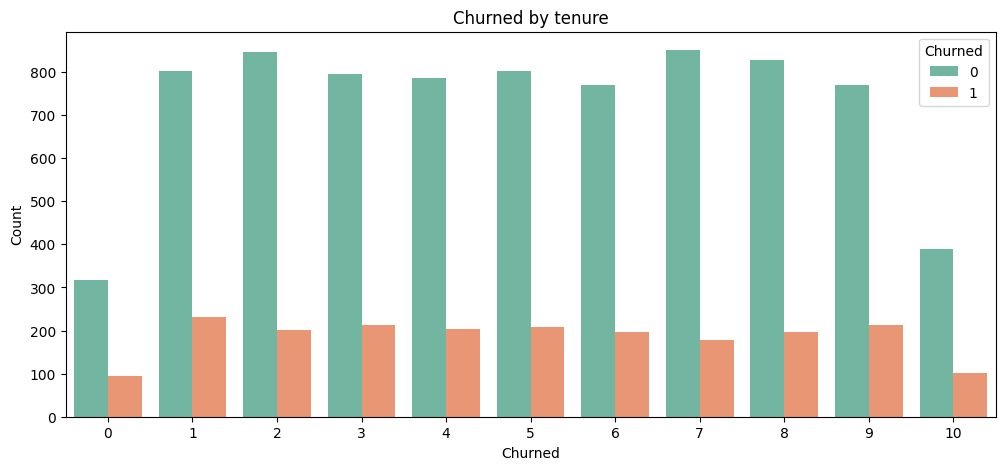

In [67]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Tenure', hue='Churned', palette='Set2')
plt.title('Churned by tenure')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [68]:
crosstab = pd.crosstab(df['Tenure'],df['Churned'])
crosstab

Churned,0,1
Tenure,,
0,318,95
1,803,232
2,847,201
3,796,213
4,786,203
5,803,209
6,771,196
7,851,177
8,828,197


In [69]:
rs = stats.chi2_contingency(crosstab)
print('pval : ',rs[1])
print(rs[3])

if rs[1] < 0.05 : 
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

pval :  0.17758462026413294
[[328.8719  84.1281]
 [824.1705 210.8295]
 [834.5224 213.4776]
 [803.4667 205.5333]
 [787.5407 201.4593]
 [805.8556 206.1444]
 [770.0221 196.9779]
 [818.5964 209.4036]
 [816.2075 208.7925]
 [783.5592 200.4408]
 [390.187   99.813 ]]
There is not a significant difference ---> H0 is not rejacted


#### This means that a "long-standing" customer in the data is almost as likely to leave as a "new" customer. Time loyalty here does not provide immunity against leaving the service, reinforcing the hypothesis that the bank may be misinterpreting the concept of loyalty among customers who have effectively stopped using their accounts but have not officially closed them.

---------------------------
- ##### **Effect of number of product on possibility of leaving**
---------------------------


In [72]:
crosstab = pd.crosstab(df['Number Of Products'],df['Churned'])
crosstab

Churned,0,1
Number Of Products,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


In [73]:
rs = stats.chi2_contingency(crosstab)
print('pval : ',rs[1])
print(rs[3])

if rs[1] < 0.05 : 
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

pval :  0.0
[[4048.3892 1035.6108]
 [3655.017   934.983 ]
 [ 211.8158   54.1842]
 [  47.778    12.222 ]]
There is a significant difference ---> H0 is rejected


-------------------------------
-------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### ****

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "bank customer churn analysis.ipynb"

[NbConvertApp] Converting notebook bank customer churn analysis.ipynb to html
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 31 image(s).
[NbConvertApp] Writing 1553483 bytes to bank customer churn analysis.html
